In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import thermoift.PLOT_SETTINGS as ps
from pysr import PySRRegressor
from sympy.parsing.sympy_parser import parse_expr
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
df = pd.read_csv("CSV_OLD/interfacial_results_cleaned.csv")


target      = ["P_bubble", "P_dew"]
exclude1    = ["gamma", "interfacial_thickness", "E_carbon dioxide", "E_argon", "E_hydrogen"]
exclude2    = ["x_carbon dioxide", "x_argon", "x_hydrogen", "y_carbon dioxide", "y_argon", "y_hydrogen"]
exclude3    = ["z_carbon dioxide"]
exclude4    = ["liquid_density", "vapor_density"]
exclude5    = ["pressure"]
exclude     = exclude1 + exclude2 + exclude3 +  exclude4 + exclude5 + target

features    = [col for col in df.columns if col not in target and col not in exclude]
print(features)

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=85)

print(f"Training: {X_train.shape[0]} rows")
print(f"Testing:  {X_test.shape[0]} rows")

['temperature', 'z_hydrogen', 'z_argon', 'Tc', 'Pc']
Training: 5757 rows
Testing:  1440 rows


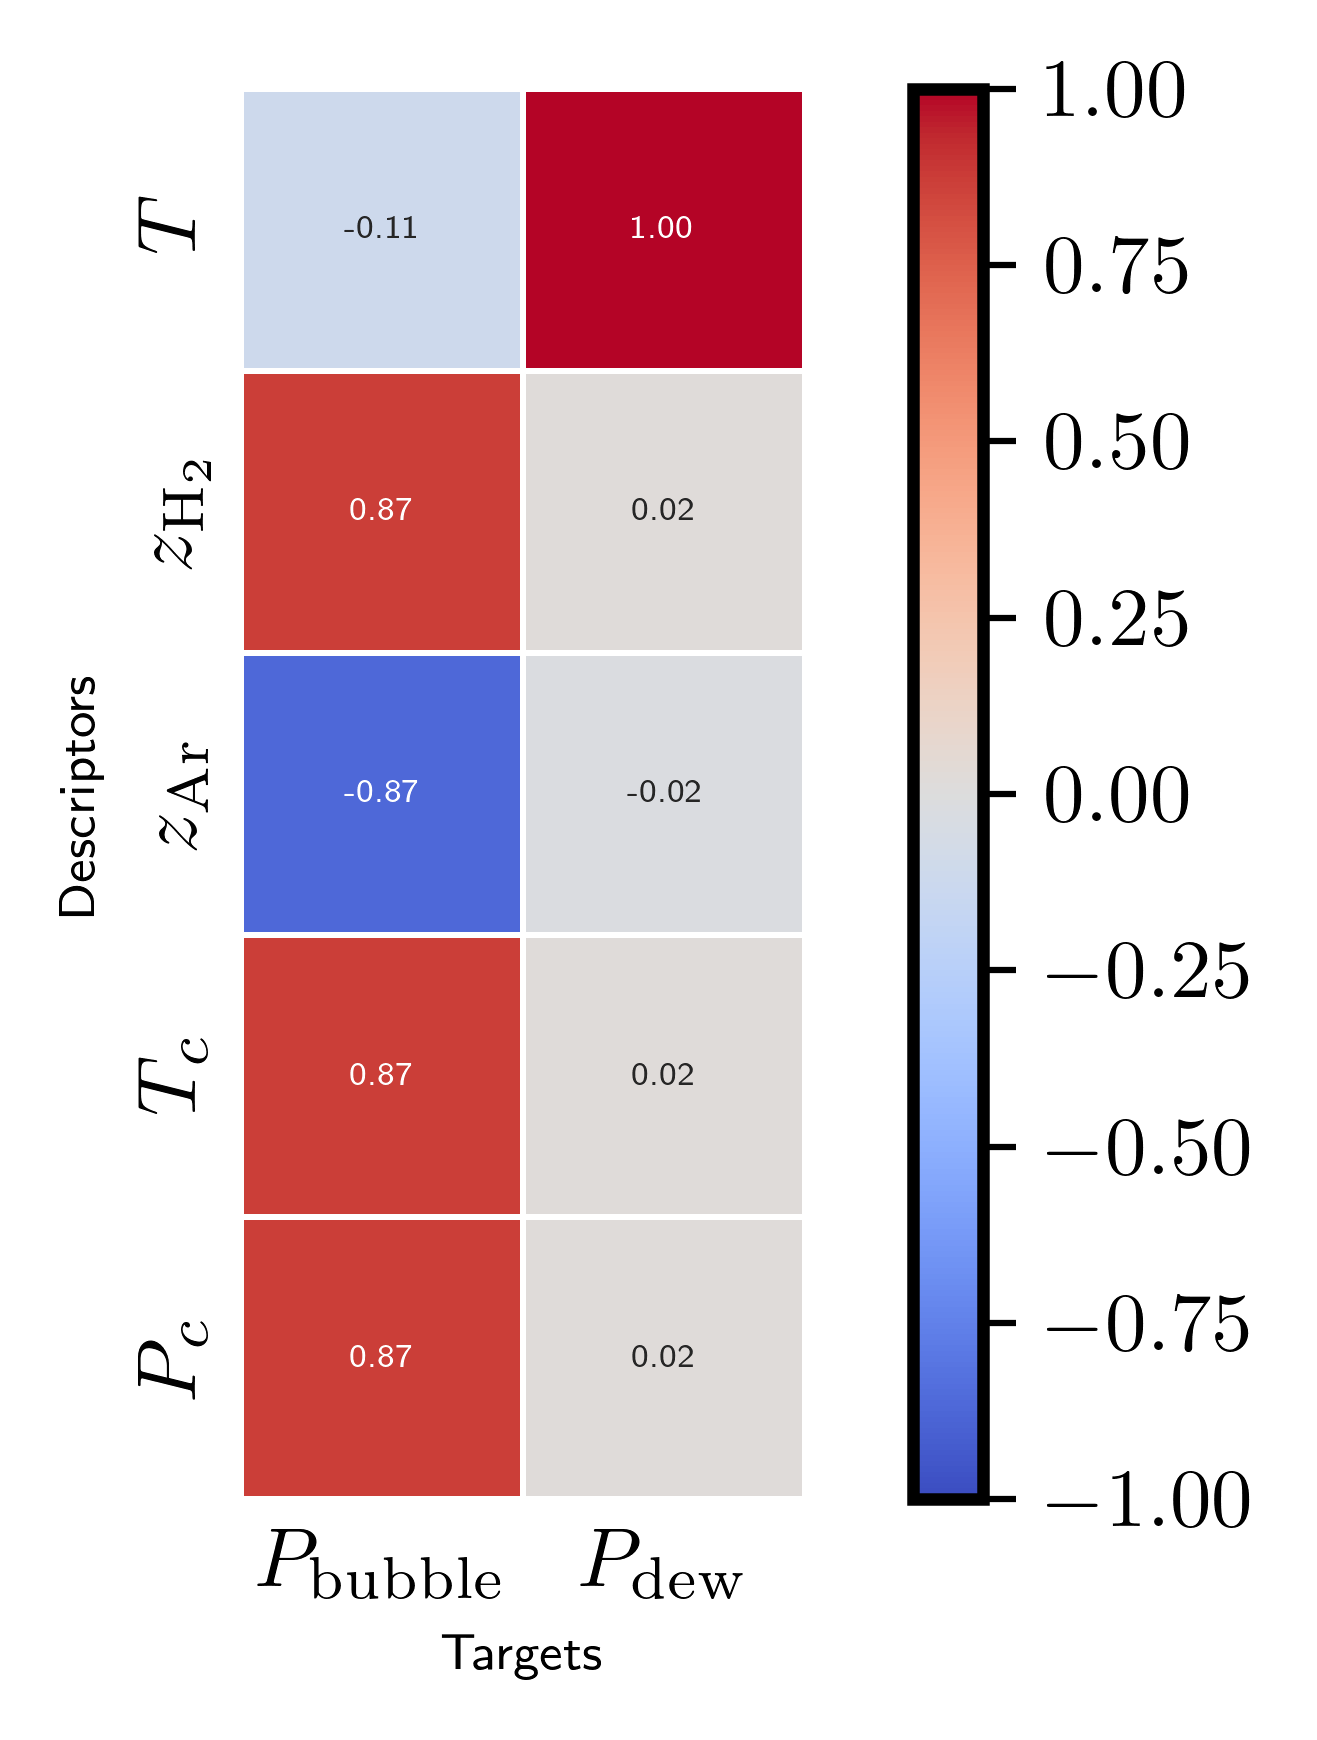

In [4]:
# ── Spearman via pandas ───────────────────────────────────────────────────────
subset      = df[features + target]
spearman_ft = subset.corr(method="spearman").loc[features, target]

# ── Labels ────────────────────────────────────────────────────────────────────
feature_label_map = {
    "temperature"      : r"$T$",
    "pressure"         : r"$P$",
    "Tc"               : r"$T_c$",
    "Pc"               : r"$P_c$",
    "liquid_density"   : r"$\rho^{\mathrm{Liq}}$",
    "vapor_density"    : r"$\rho^{\mathrm{Vap}}$",
    "z_carbon dioxide" : r"$z_{\mathrm{CO_2}}$",
    "z_argon"          : r"$z_{\mathrm{Ar}}$",
    "z_hydrogen"       : r"$z_{\mathrm{H_2}}$",
}

target_label_map = {
    "P_bubble" : r"$P_{\mathrm{bubble}}$",
    "P_dew"    : r"$P_{\mathrm{dew}}$",
}

spearman_ft = spearman_ft.rename(index=feature_label_map, columns=target_label_map)

fig, ax = ps.plot_init()

cm = sns.heatmap(
    spearman_ft,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap=ps.map,
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 4},
    cbar_kws={"shrink": 1}
)

cbar = cm.collections[0].colorbar

ps.style_colorbar(cbar)
ax.set_xlabel("Targets", fontsize=6)
ax.set_ylabel("Descriptors",fontsize=6)

ps.apply_axis_style(ax)
ax.tick_params(axis="both", length=0)

# ax.set_xticklabels(ax.get_xticklabels(), fontsize=3)
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=3)
# cbar.ax.tick_params(labelsize=3)

plt.tight_layout()
ps.save_plot(fig, "spearman_features_dew_bubble")
plt.show()

In [5]:
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)
y_pred_LR = model_LR.predict(X_test)

for i, t in enumerate(target):
    r2   = r2_score(y_test.iloc[:, i], y_pred_LR[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_LR[:, i]))
    print(f"{t:12s} --> R2 = {r2:.4f}  |  RMSE = {rmse:.4f}")

P_bubble     --> R2 = 0.6416  |  RMSE = 17.6787
P_dew        --> R2 = 0.9072  |  RMSE = 5.8116


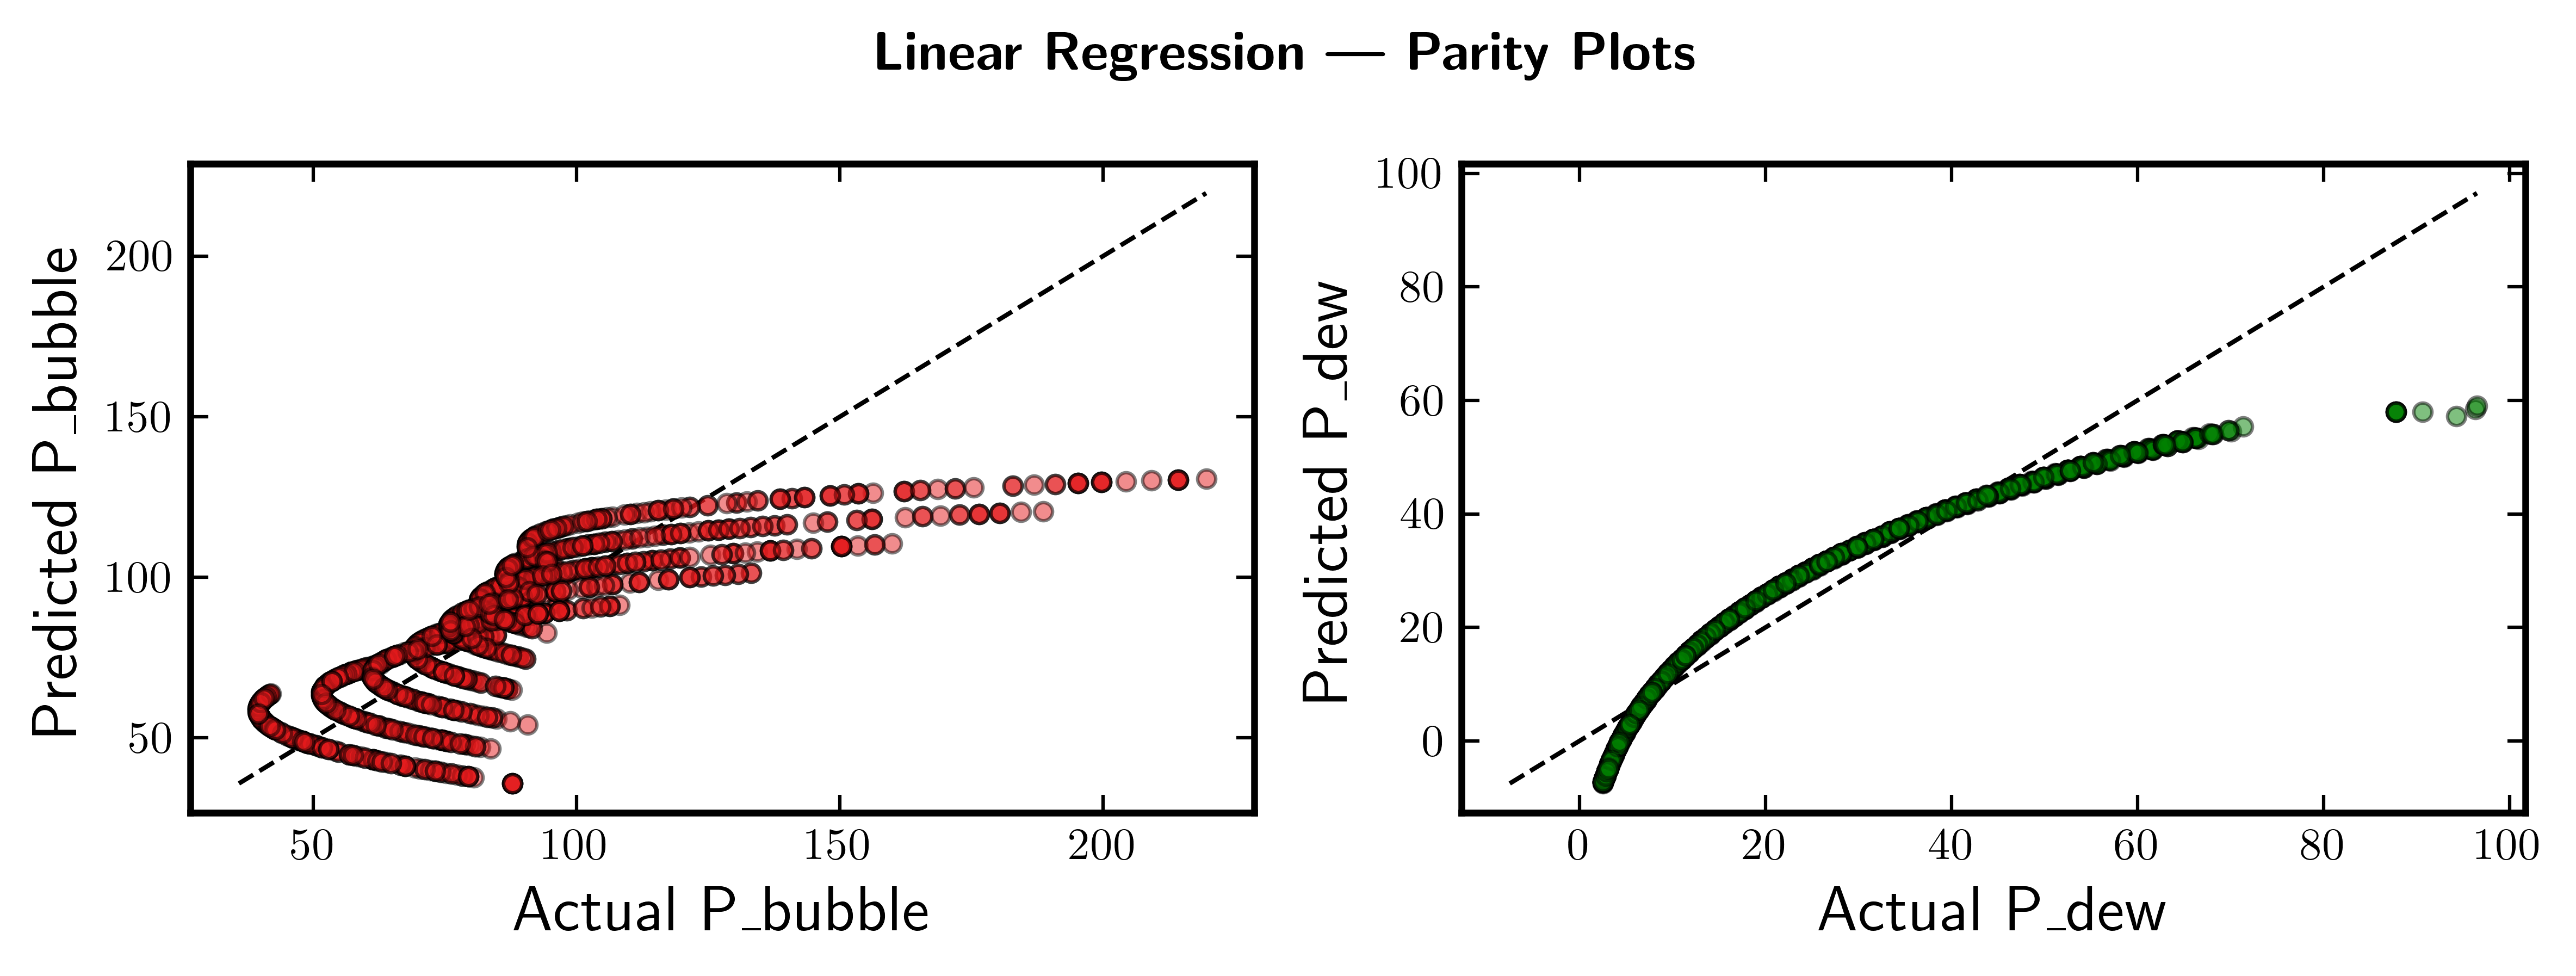

In [6]:
fig, axes = ps.plot_init_multi(1, 2, w=8, h=3)

for i, (t, ax) in enumerate(zip(target, axes)):
    t_label = ps.label_map.get(t, t)
    r2      = r2_score(y_test.iloc[:, i], y_pred_LR[:, i])

    ax.scatter(
        y_test.iloc[:, i], y_pred_LR[:, i],
        color=ps.colors[i],
        edgecolors="black",
        linewidths=ps.markeredgewidth,
        s=ps.markersize ** 2,
        alpha=ps.alpha,
        zorder=3,
    )

    lims = [min(y_test.iloc[:, i].min(), y_pred_LR[:, i].min()),
            max(y_test.iloc[:, i].max(), y_pred_LR[:, i].max())]
    ax.plot(lims, lims, "k--", linewidth=ps.linewidth)

    ax.set_xlabel(rf"Actual {t_label}",    fontsize=ps.label_fontsize)
    ax.set_ylabel(rf"Predicted {t_label}", fontsize=ps.label_fontsize)
    # ax.set_title(rf"{t_label} \ \ $R^2 = {r2:.3f}$",
    #              fontsize=ps.title_fontsize, fontweight="bold")
    # ps.style_legend(ax, loc="upper left")

plt.suptitle(r"\textbf{Linear Regression --- Parity Plots}",
             fontsize=ps.title_fontsize)
plt.tight_layout()
ps.save_plot(fig, "parity_plots_linear_regression")
plt.show()

In [7]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=5555500)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

for i, t in enumerate(target):
    r2   = r2_score(y_test.iloc[:, i], y_pred_rf[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_rf[:, i]))
    print(f"{t:12s} --> R2 = {r2:.4f}  |  RMSE = {rmse:.4f}")

P_bubble     --> R2 = 1.0000  |  RMSE = 0.0672
P_dew        --> R2 = 0.9996  |  RMSE = 0.3867


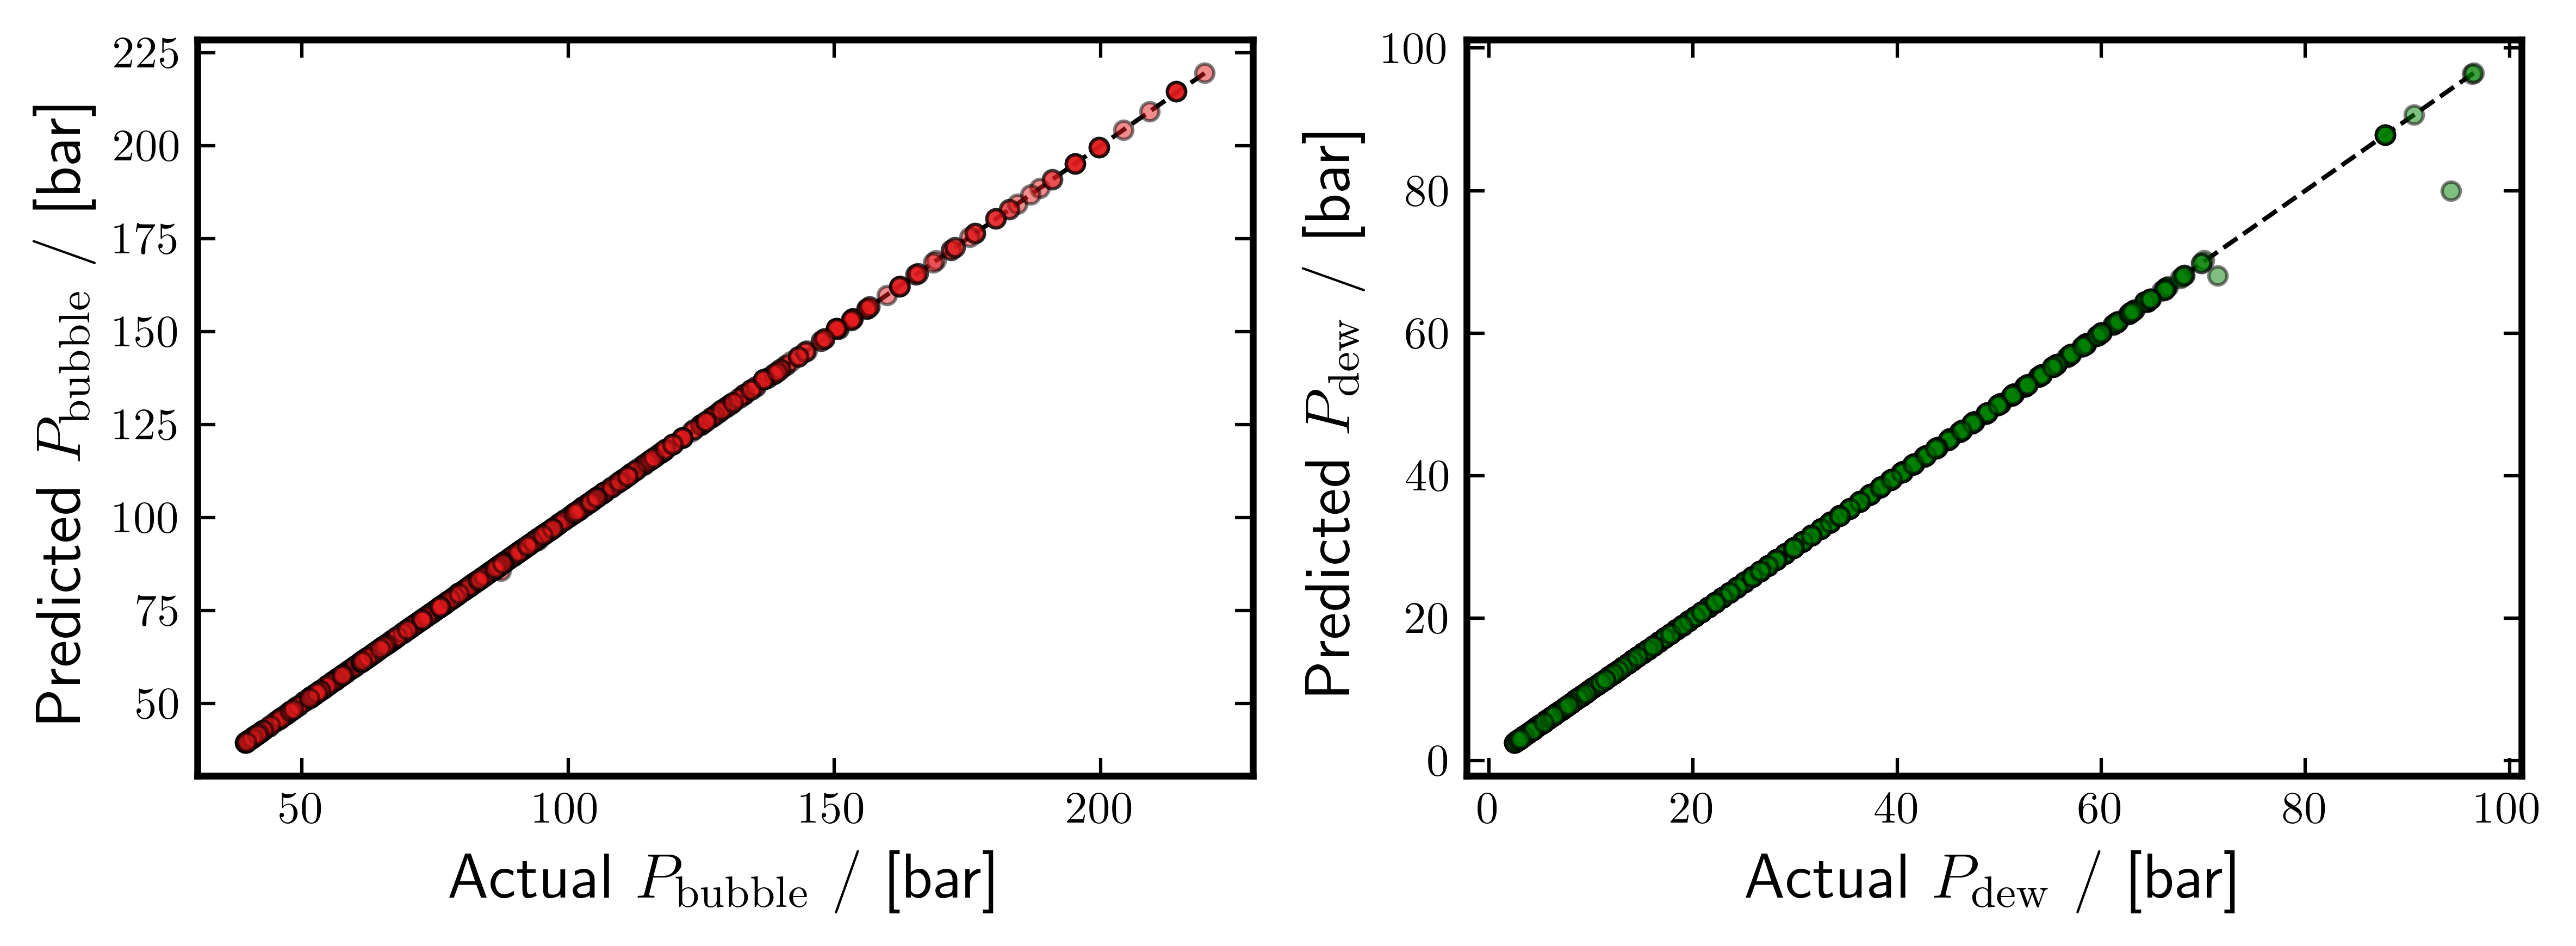

In [8]:
fig, axes = ps.plot_init_multi(1, 2, w=8, h=3)

for i, (t, ax) in enumerate(zip(target, axes)):
    t_label = ps.label_map.get(t.lower(), t)
    r2      = r2_score(y_test.iloc[:, i], y_pred_rf[:, i])

    ax.scatter(
        y_test.iloc[:, i], y_pred_rf[:, i],
        color=ps.colors[i],
        edgecolors="black",
        linewidths=ps.markeredgewidth,
        s=ps.markersize ** 2,
        alpha=ps.alpha,
        zorder=3,
    )

    lims = [min(y_test.iloc[:, i].min(), y_pred_rf[:, i].min()),
            max(y_test.iloc[:, i].max(), y_pred_rf[:, i].max())]
    ax.plot(lims, lims, "k--", linewidth=ps.linewidth)

    ax.set_xlabel(rf"Actual {t_label}",    fontsize=ps.label_fontsize)
    ax.set_ylabel(rf"Predicted {t_label}", fontsize=ps.label_fontsize)

# plt.suptitle(r"\textbf{Random Forest --- Parity Plots}",
#              fontsize=ps.title_fontsize)
plt.tight_layout()
ps.save_plot(fig, "parity_plots_random_forest")
plt.show()

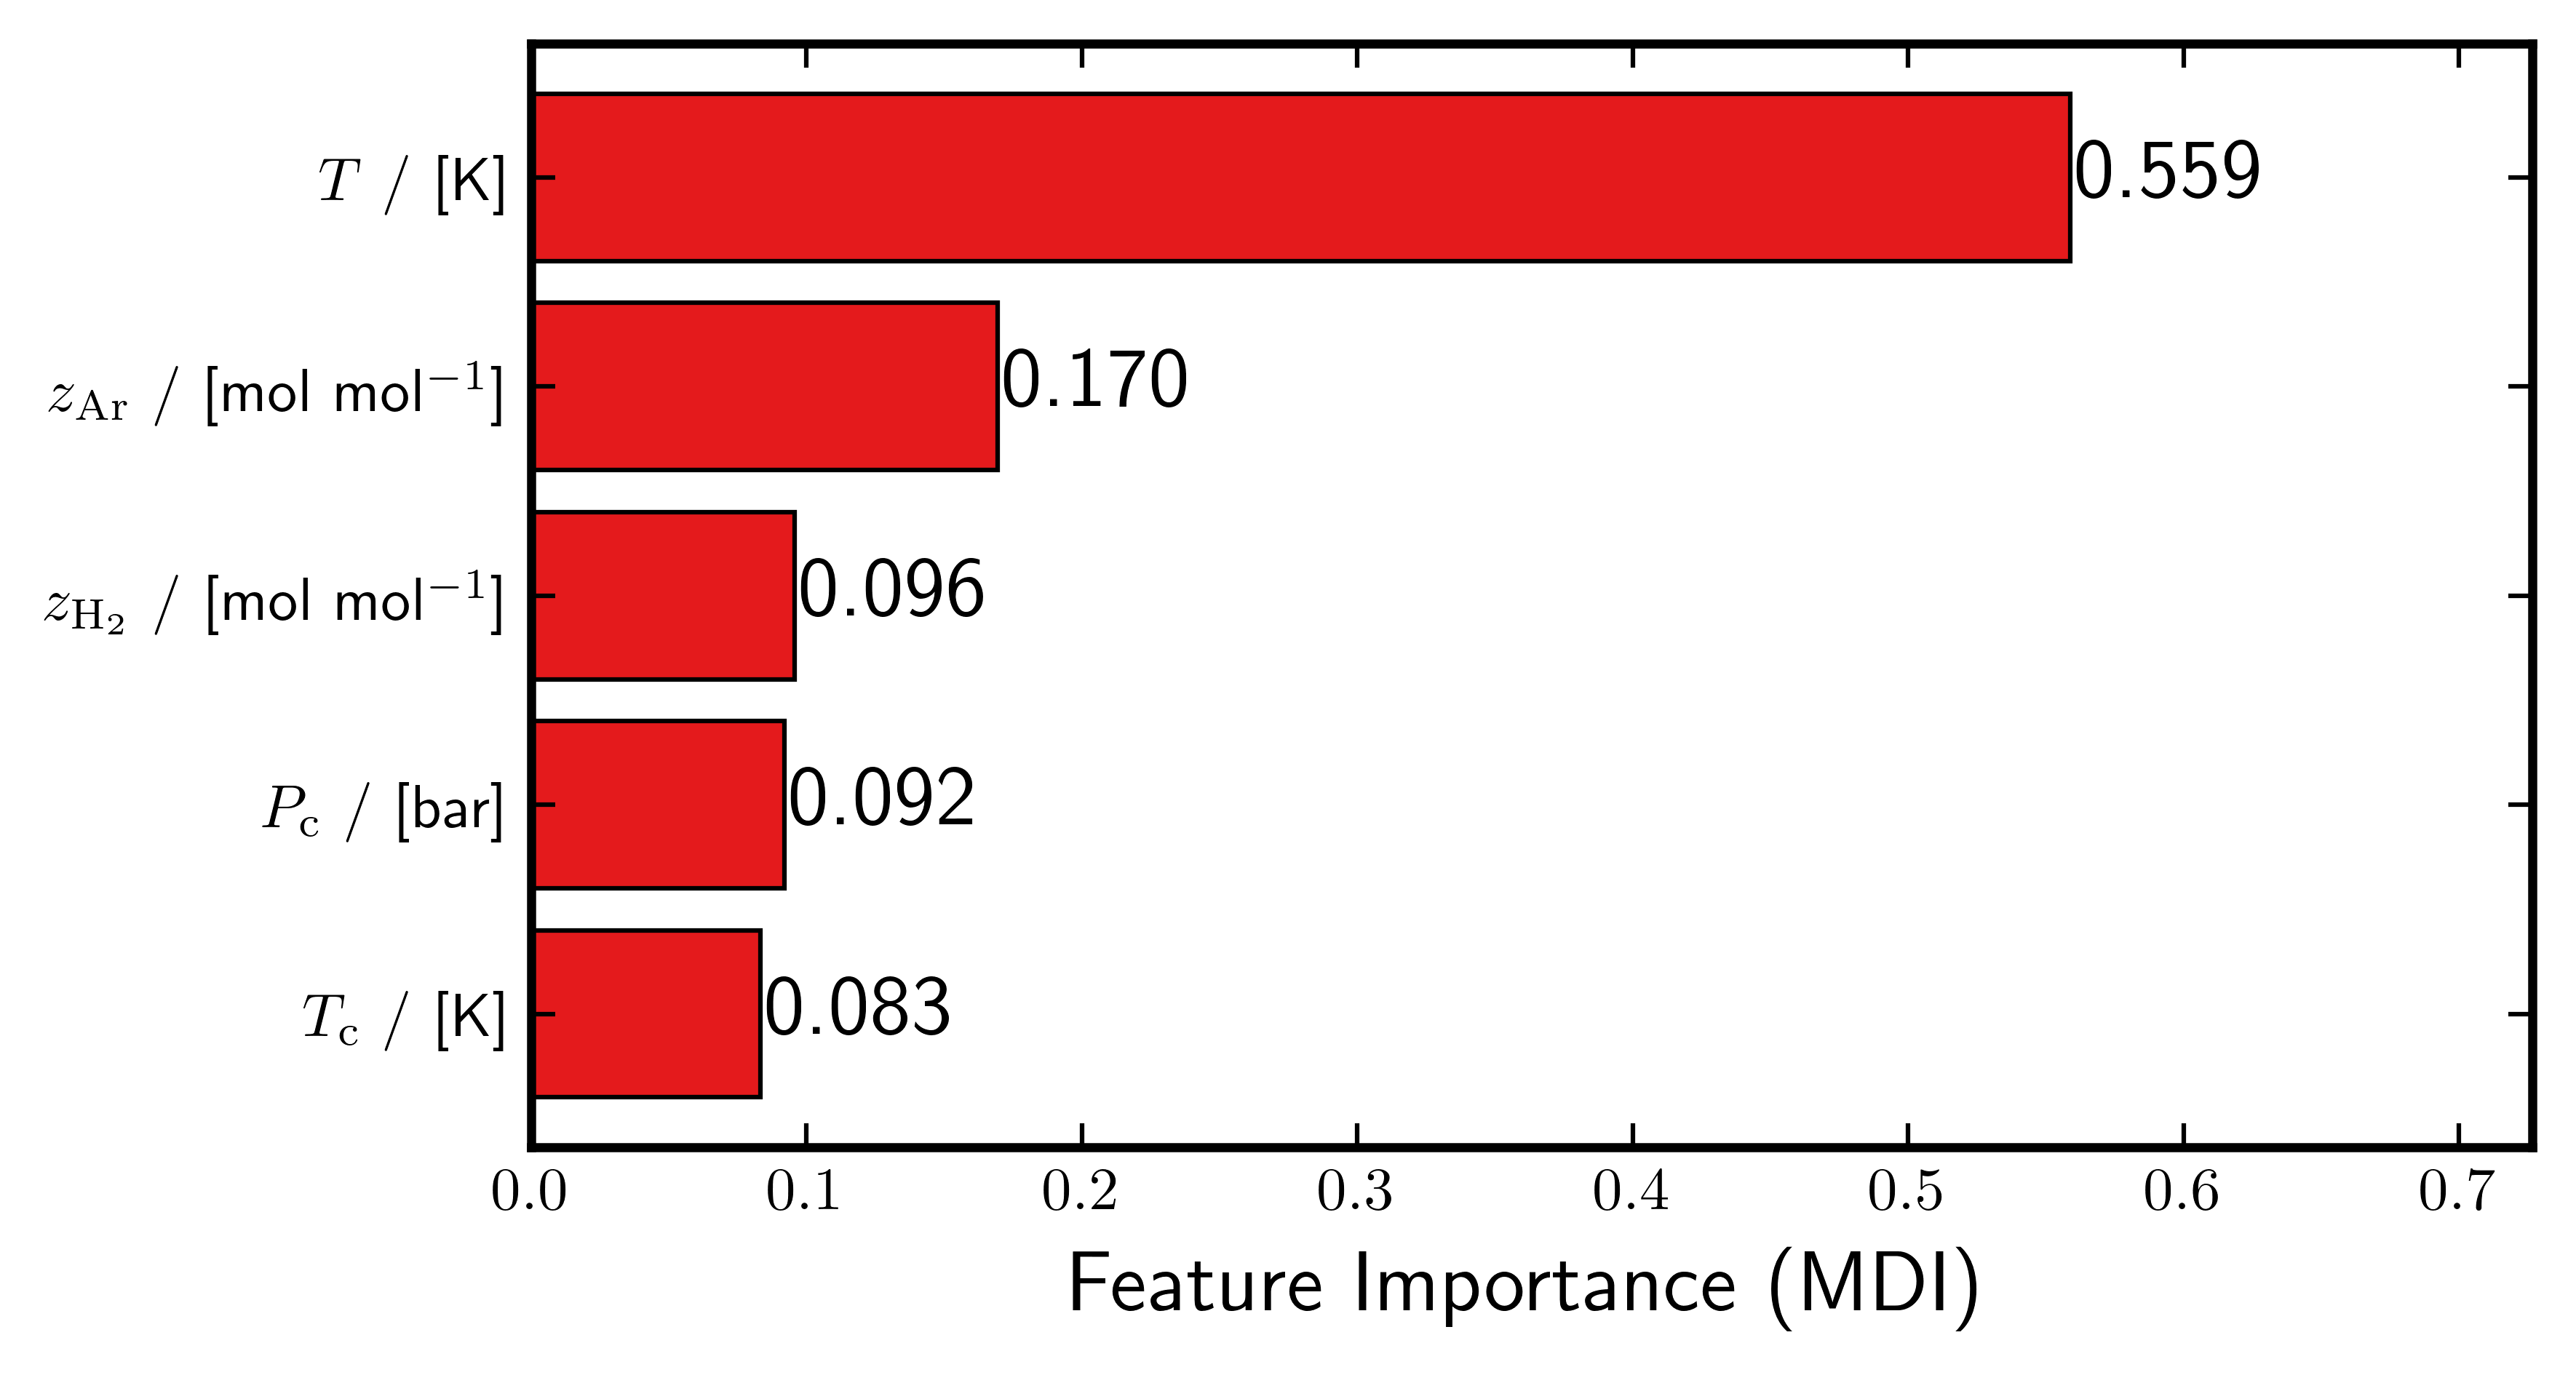

In [9]:
descriptors = X_train.columns
importances = model_rf.feature_importances_

fi_df = pd.DataFrame({
    "Descriptor": descriptors,
    "Importance": importances
}).sort_values("Importance", ascending=True)

fi_df["Label"] = fi_df["Descriptor"].map(lambda x: ps.label_map.get(x.lower(), x))

fig, ax = ps.plot_init_multi(1, 1, w=6, h=len(descriptors) * 0.45 + 1)

bars = ax.barh(
    fi_df["Label"],
    fi_df["Importance"],
    color=ps.colors[0],
    edgecolor="black",
    linewidth=ps.markeredgewidth,
)

for bar, val in zip(bars, fi_df["Importance"]):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{val:.3f}",
        va="center",
        fontsize=ps.label_fontsize
    )

ax.set_xlabel("Feature Importance (MDI)", fontsize=ps.label_fontsize)
ax.set_xlim(0, fi_df["Importance"].max() * 1.3)

plt.tight_layout()
# ps.save_plot(fig, "feature_importance_random_forest")
plt.show()

In [10]:

degrees = [1, 2, 3]
results = {}

sym_vars = {
    name: sp.Symbol(ps.symbol_map.get(name.lower(), name))
    for name in X_train.columns
}

for degree in degrees:
    model_poly = Pipeline([
        ("poly",   PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])
    model_poly.fit(X_train, y_train)
    y_pred_poly = model_poly.predict(X_test)

    poly       = model_poly.named_steps["poly"]
    linear     = model_poly.named_steps["linear"]
    feat_names = poly.get_feature_names_out(X_train.columns)
    coef_df    = pd.DataFrame(
                    linear.coef_,
                    index=target,
                    columns=feat_names
                 )

    equations = {}
    for t_idx, t in enumerate(target):
        expr = sp.Float(float(f"{linear.intercept_[t_idx]:.4g}"))

        for fname, coef in zip(feat_names, linear.coef_[t_idx]):
            coef_rounded = float(f"{coef:.4g}")
            if coef_rounded == 0:
                continue

            term = sp.Integer(1)
            for part in fname.split(" "):
                if "^" in part:
                    var, exp = part.split("^")
                    term *= sym_vars[var] ** int(exp) 
                else:
                    term *= sym_vars[part]

            expr += sp.Float(coef_rounded) * term

        equations[t] = expr

    results[degree] = {
        "y_pred"    : y_pred_poly,
        "r2"        : [r2_score(y_test.iloc[:, i], y_pred_poly[:, i]) for i in range(len(target))],
        "rmse"      : [np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_poly[:, i])) for i in range(len(target))],
        "residuals" : y_test.values - y_pred_poly,
        "coef"      : coef_df,
        "intercept" : linear.intercept_,
        "equations" : equations,
    }

# --- display equations ---
from IPython.display import display
for degree in degrees:
    print(f"\nDegree {degree}:")
    for t, eq in results[degree]["equations"].items():
        t_sym = sp.Symbol(ps.symbol_map.get(t.lower(), t))
        display(sp.Eq(t_sym, eq))


Degree 1:


Eq(P_{\mathrm{bubble}}, 80.72*P_{\mathrm{c}} - 0.2746*T + 18.78*T_{\mathrm{c}} + 8021.0*z_{\mathrm{Ar}} - 8021.0*z_{\mathrm{H_2}} - 13150.0)

Eq(P_{\mathrm{dew}}, 0.1885*P_{\mathrm{c}} + 0.6391*T - 8.284*T_{\mathrm{c}} - 98.95*z_{\mathrm{Ar}} + 98.95*z_{\mathrm{H_2}} + 2383.0)


Degree 2:


Eq(P_{\mathrm{bubble}}, -110.2*P_{\mathrm{c}}**2 - 5.034*P_{\mathrm{c}}*T + 139.9*P_{\mathrm{c}}*T_{\mathrm{c}} - 10740.0*P_{\mathrm{c}}*z_{\mathrm{Ar}} + 9690.0*P_{\mathrm{c}}*z_{\mathrm{H_2}} - 20950.0*P_{\mathrm{c}} + 0.01379*T**2 - 1.424*T*T_{\mathrm{c}} - 515.8*T*z_{\mathrm{Ar}} + 560.8*T*z_{\mathrm{H_2}} + 899.0*T - 17.22*T_{\mathrm{c}}**2 + 3490.0*T_{\mathrm{c}}*z_{\mathrm{Ar}} - 3596.0*T_{\mathrm{c}}*z_{\mathrm{H_2}} - 2118.0*T_{\mathrm{c}} + 109.7*z_{\mathrm{Ar}}**2 - 103.5*z_{\mathrm{Ar}}*z_{\mathrm{H_2}} + 122.6*z_{\mathrm{Ar}} + 97.42*z_{\mathrm{H_2}}**2 - 122.6*z_{\mathrm{H_2}} + 1185000.0)

Eq(P_{\mathrm{dew}}, -290.1*P_{\mathrm{c}}**2 + 0.02969*P_{\mathrm{c}}*T + 368.8*P_{\mathrm{c}}*T_{\mathrm{c}} - 28160.0*P_{\mathrm{c}}*z_{\mathrm{Ar}} + 25230.0*P_{\mathrm{c}}*z_{\mathrm{H_2}} - 58640.0*P_{\mathrm{c}} + 0.007759*T**2 - 0.2883*T*T_{\mathrm{c}} + 0.9217*T*z_{\mathrm{Ar}} + 3.185*T*z_{\mathrm{H_2}} + 82.13*T - 46.25*T_{\mathrm{c}}**2 + 7960.0*T_{\mathrm{c}}*z_{\mathrm{Ar}} - 8259.0*T_{\mathrm{c}}*z_{\mathrm{H_2}} - 5985.0*T_{\mathrm{c}} + 283.1*z_{\mathrm{Ar}}**2 - 266.3*z_{\mathrm{Ar}}*z_{\mathrm{H_2}} + 335.5*z_{\mathrm{Ar}} + 249.6*z_{\mathrm{H_2}}**2 - 335.5*z_{\mathrm{H_2}} + 3640000.0)


Degree 3:


Eq(P_{\mathrm{bubble}}, 0.04874*P_{\mathrm{c}}**3 - 0.01839*P_{\mathrm{c}}**2*T + 0.07075*P_{\mathrm{c}}**2*T_{\mathrm{c}} + 5.465*P_{\mathrm{c}}**2*z_{\mathrm{Ar}} - 5.537*P_{\mathrm{c}}**2*z_{\mathrm{H_2}} - 1.435*P_{\mathrm{c}}**2 + 0.1224*P_{\mathrm{c}}*T**2 - 0.2202*P_{\mathrm{c}}*T*T_{\mathrm{c}} - 1.67*P_{\mathrm{c}}*T*z_{\mathrm{Ar}} + 2.183*P_{\mathrm{c}}*T*z_{\mathrm{H_2}} + 10.26*P_{\mathrm{c}}*T + 0.02633*P_{\mathrm{c}}*T_{\mathrm{c}}**2 + 7.507*P_{\mathrm{c}}*T_{\mathrm{c}}*z_{\mathrm{Ar}} - 7.527*P_{\mathrm{c}}*T_{\mathrm{c}}*z_{\mathrm{H_2}} - 0.4045*P_{\mathrm{c}}*T_{\mathrm{c}} - 0.02952*P_{\mathrm{c}}*z_{\mathrm{Ar}}**2 + 0.03097*P_{\mathrm{c}}*z_{\mathrm{Ar}}*z_{\mathrm{H_2}} + 0.02911*P_{\mathrm{c}}*z_{\mathrm{Ar}} - 0.03243*P_{\mathrm{c}}*z_{\mathrm{H_2}}**2 - 0.02917*P_{\mathrm{c}}*z_{\mathrm{H_2}} - 0.001112*P_{\mathrm{c}} - 7.117e-5*T**3 + 0.03733*T**2*T_{\mathrm{c}} + 12.82*T**2*z_{\mathrm{Ar}} - 13.96*T**2*z_{\mathrm{H_2}} - 22.79*T**2 - 0.05226*T*T_{\mathrm{c

Eq(P_{\mathrm{dew}}, -1.024*P_{\mathrm{c}}**3 - 0.6225*P_{\mathrm{c}}**2*T + 0.07011*P_{\mathrm{c}}**2*T_{\mathrm{c}} - 99.51*P_{\mathrm{c}}**2*z_{\mathrm{Ar}} + 96.31*P_{\mathrm{c}}**2*z_{\mathrm{H_2}} - 64.13*P_{\mathrm{c}}**2 + 0.0008052*P_{\mathrm{c}}*T**2 + 0.7962*P_{\mathrm{c}}*T*T_{\mathrm{c}} - 60.59*P_{\mathrm{c}}*T*z_{\mathrm{Ar}} + 54.18*P_{\mathrm{c}}*T*z_{\mathrm{H_2}} - 128.2*P_{\mathrm{c}}*T + 1.066*P_{\mathrm{c}}*T_{\mathrm{c}}**2 - 42.53*P_{\mathrm{c}}*T_{\mathrm{c}}*z_{\mathrm{Ar}} + 31.92*P_{\mathrm{c}}*T_{\mathrm{c}}*z_{\mathrm{H_2}} - 212.2*P_{\mathrm{c}}*T_{\mathrm{c}} + 0.8227*P_{\mathrm{c}}*z_{\mathrm{Ar}}**2 - 0.8279*P_{\mathrm{c}}*z_{\mathrm{Ar}}*z_{\mathrm{H_2}} - 0.1024*P_{\mathrm{c}}*z_{\mathrm{Ar}} + 0.8295*P_{\mathrm{c}}*z_{\mathrm{H_2}}**2 + 0.03225*P_{\mathrm{c}}*z_{\mathrm{H_2}} - 1.403*P_{\mathrm{c}} + 6.15e-5*T**3 - 0.01382*T**2*T_{\mathrm{c}} - 0.01728*T**2*z_{\mathrm{Ar}} + 0.2228*T**2*z_{\mathrm{H_2}} + 4.111*T**2 - 0.1646*T*T_{\mathrm{c}}**2 + 18

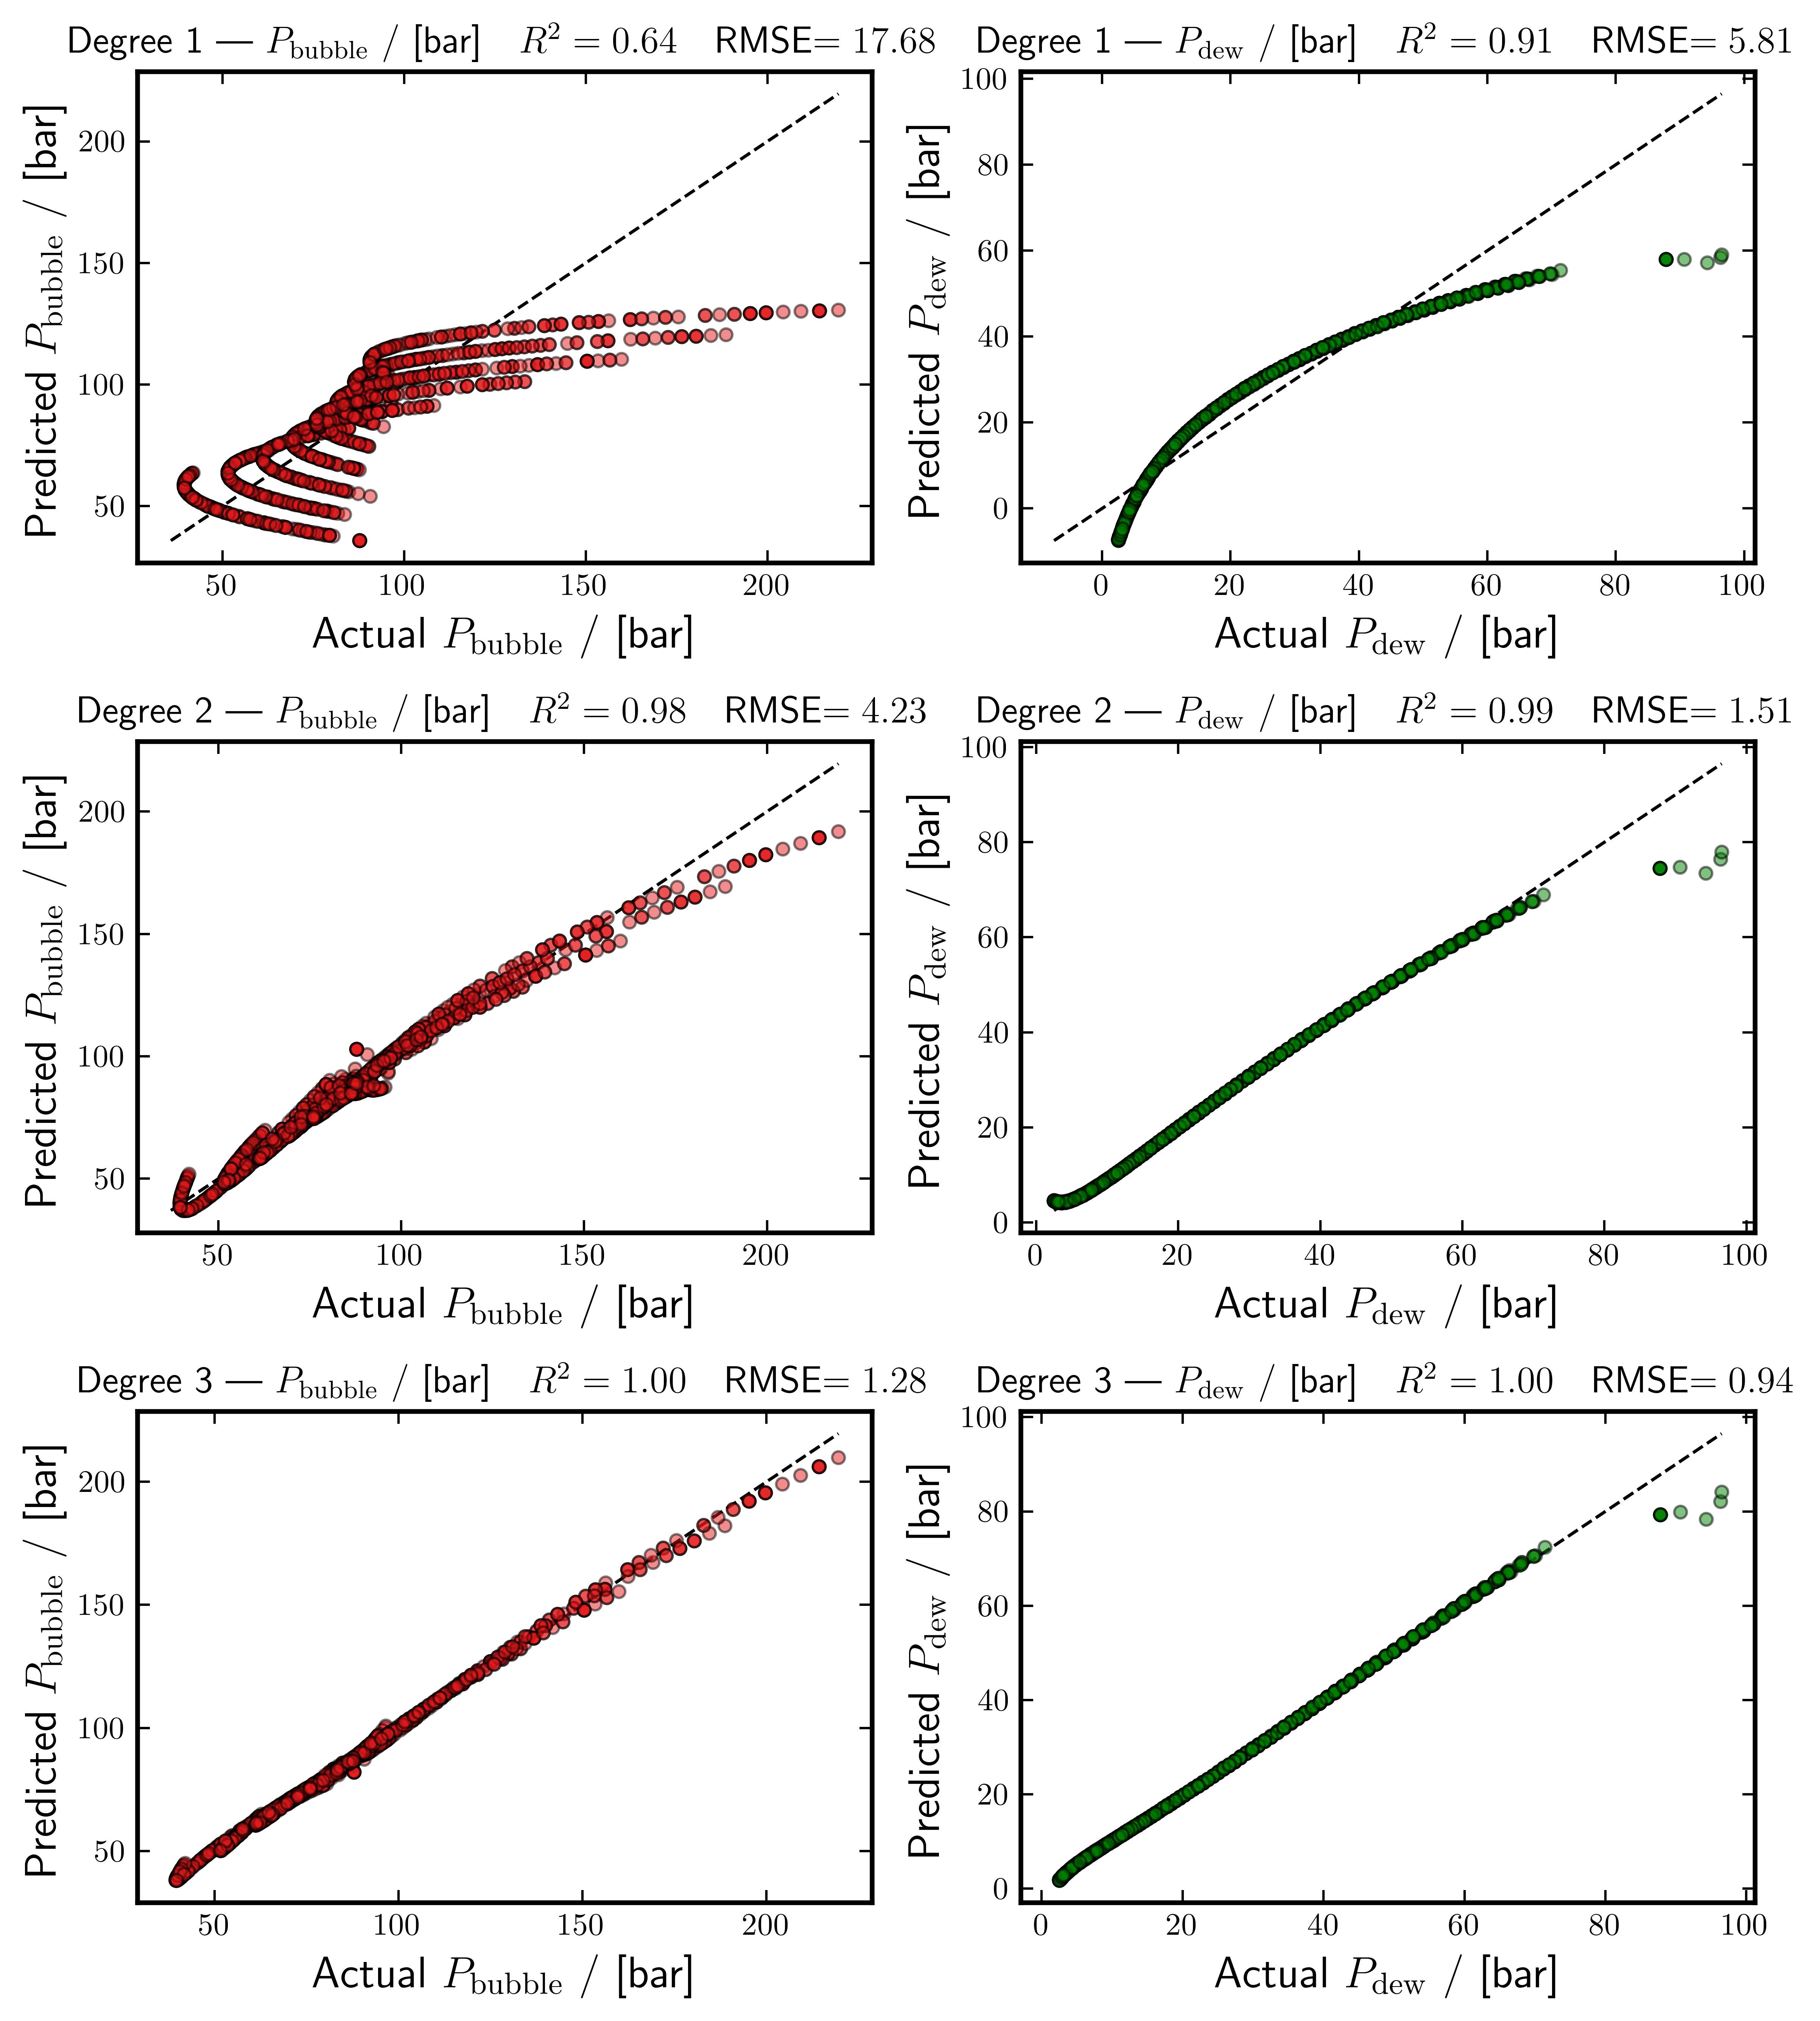

In [11]:
fig, axes = ps.plot_init_multi(3, 2, w=8, h=9)
axes = axes.flatten()

for deg_idx, degree in enumerate([1, 2, 3]):
    y_pred_poly = results[degree]["y_pred"]

    for i, t in enumerate(target):
        ax      = axes[deg_idx * 2 + i]
        t_label = ps.label_map.get(t.lower(), t)
        r2      = results[degree]["r2"][i]
        rmse    = results[degree]["rmse"][i]

        ax.scatter(
            y_test.iloc[:, i], y_pred_poly[:, i],
            color=ps.colors[i],
            edgecolors="black",
            linewidths=ps.markeredgewidth,
            s=ps.markersize ** 2,
            alpha=ps.alpha,
            zorder=3,
        )

        lims = [min(y_test.iloc[:, i].min(), y_pred_poly[:, i].min()),
                max(y_test.iloc[:, i].max(), y_pred_poly[:, i].max())]
        ax.plot(lims, lims, "k--", linewidth=ps.linewidth)

        ax.set_xlabel(rf"Actual {t_label}",    fontsize=ps.label_fontsize)
        ax.set_ylabel(rf"Predicted {t_label}", fontsize=ps.label_fontsize)
        ax.set_title(rf"Degree {degree} --- {t_label} \ \ $R^2={r2:.2f}$ \ \ RMSE$={rmse:.2f}$",
                     fontsize=ps.title_fontsize)

# plt.suptitle(r"\textbf{Polynomial Regression --- Parity Plots}",
#              fontsize=ps.title_fontsize)
plt.tight_layout()
plt.show()

Declared symbols:


Eq(temperature, T)

Eq(z_hydrogen, z_{\mathrm{H_2}})

Eq(z_argon, z_{\mathrm{Ar}})

Eq(Tc, T_{\mathrm{c}})

Eq(Pc, P_{\mathrm{c}})


Equations:

Degree 1:


Eq(P_{\mathrm{bubble}}, 80.72*P_{\mathrm{c}} - 0.2746*T + 18.78*T_{\mathrm{c}} + 8021.0*z_{\mathrm{Ar}} - 8021.0*z_{\mathrm{H_2}} - 13150.0)

Eq(P_{\mathrm{dew}}, 0.1885*P_{\mathrm{c}} + 0.6391*T - 8.284*T_{\mathrm{c}} - 98.95*z_{\mathrm{Ar}} + 98.95*z_{\mathrm{H_2}} + 2383.0)

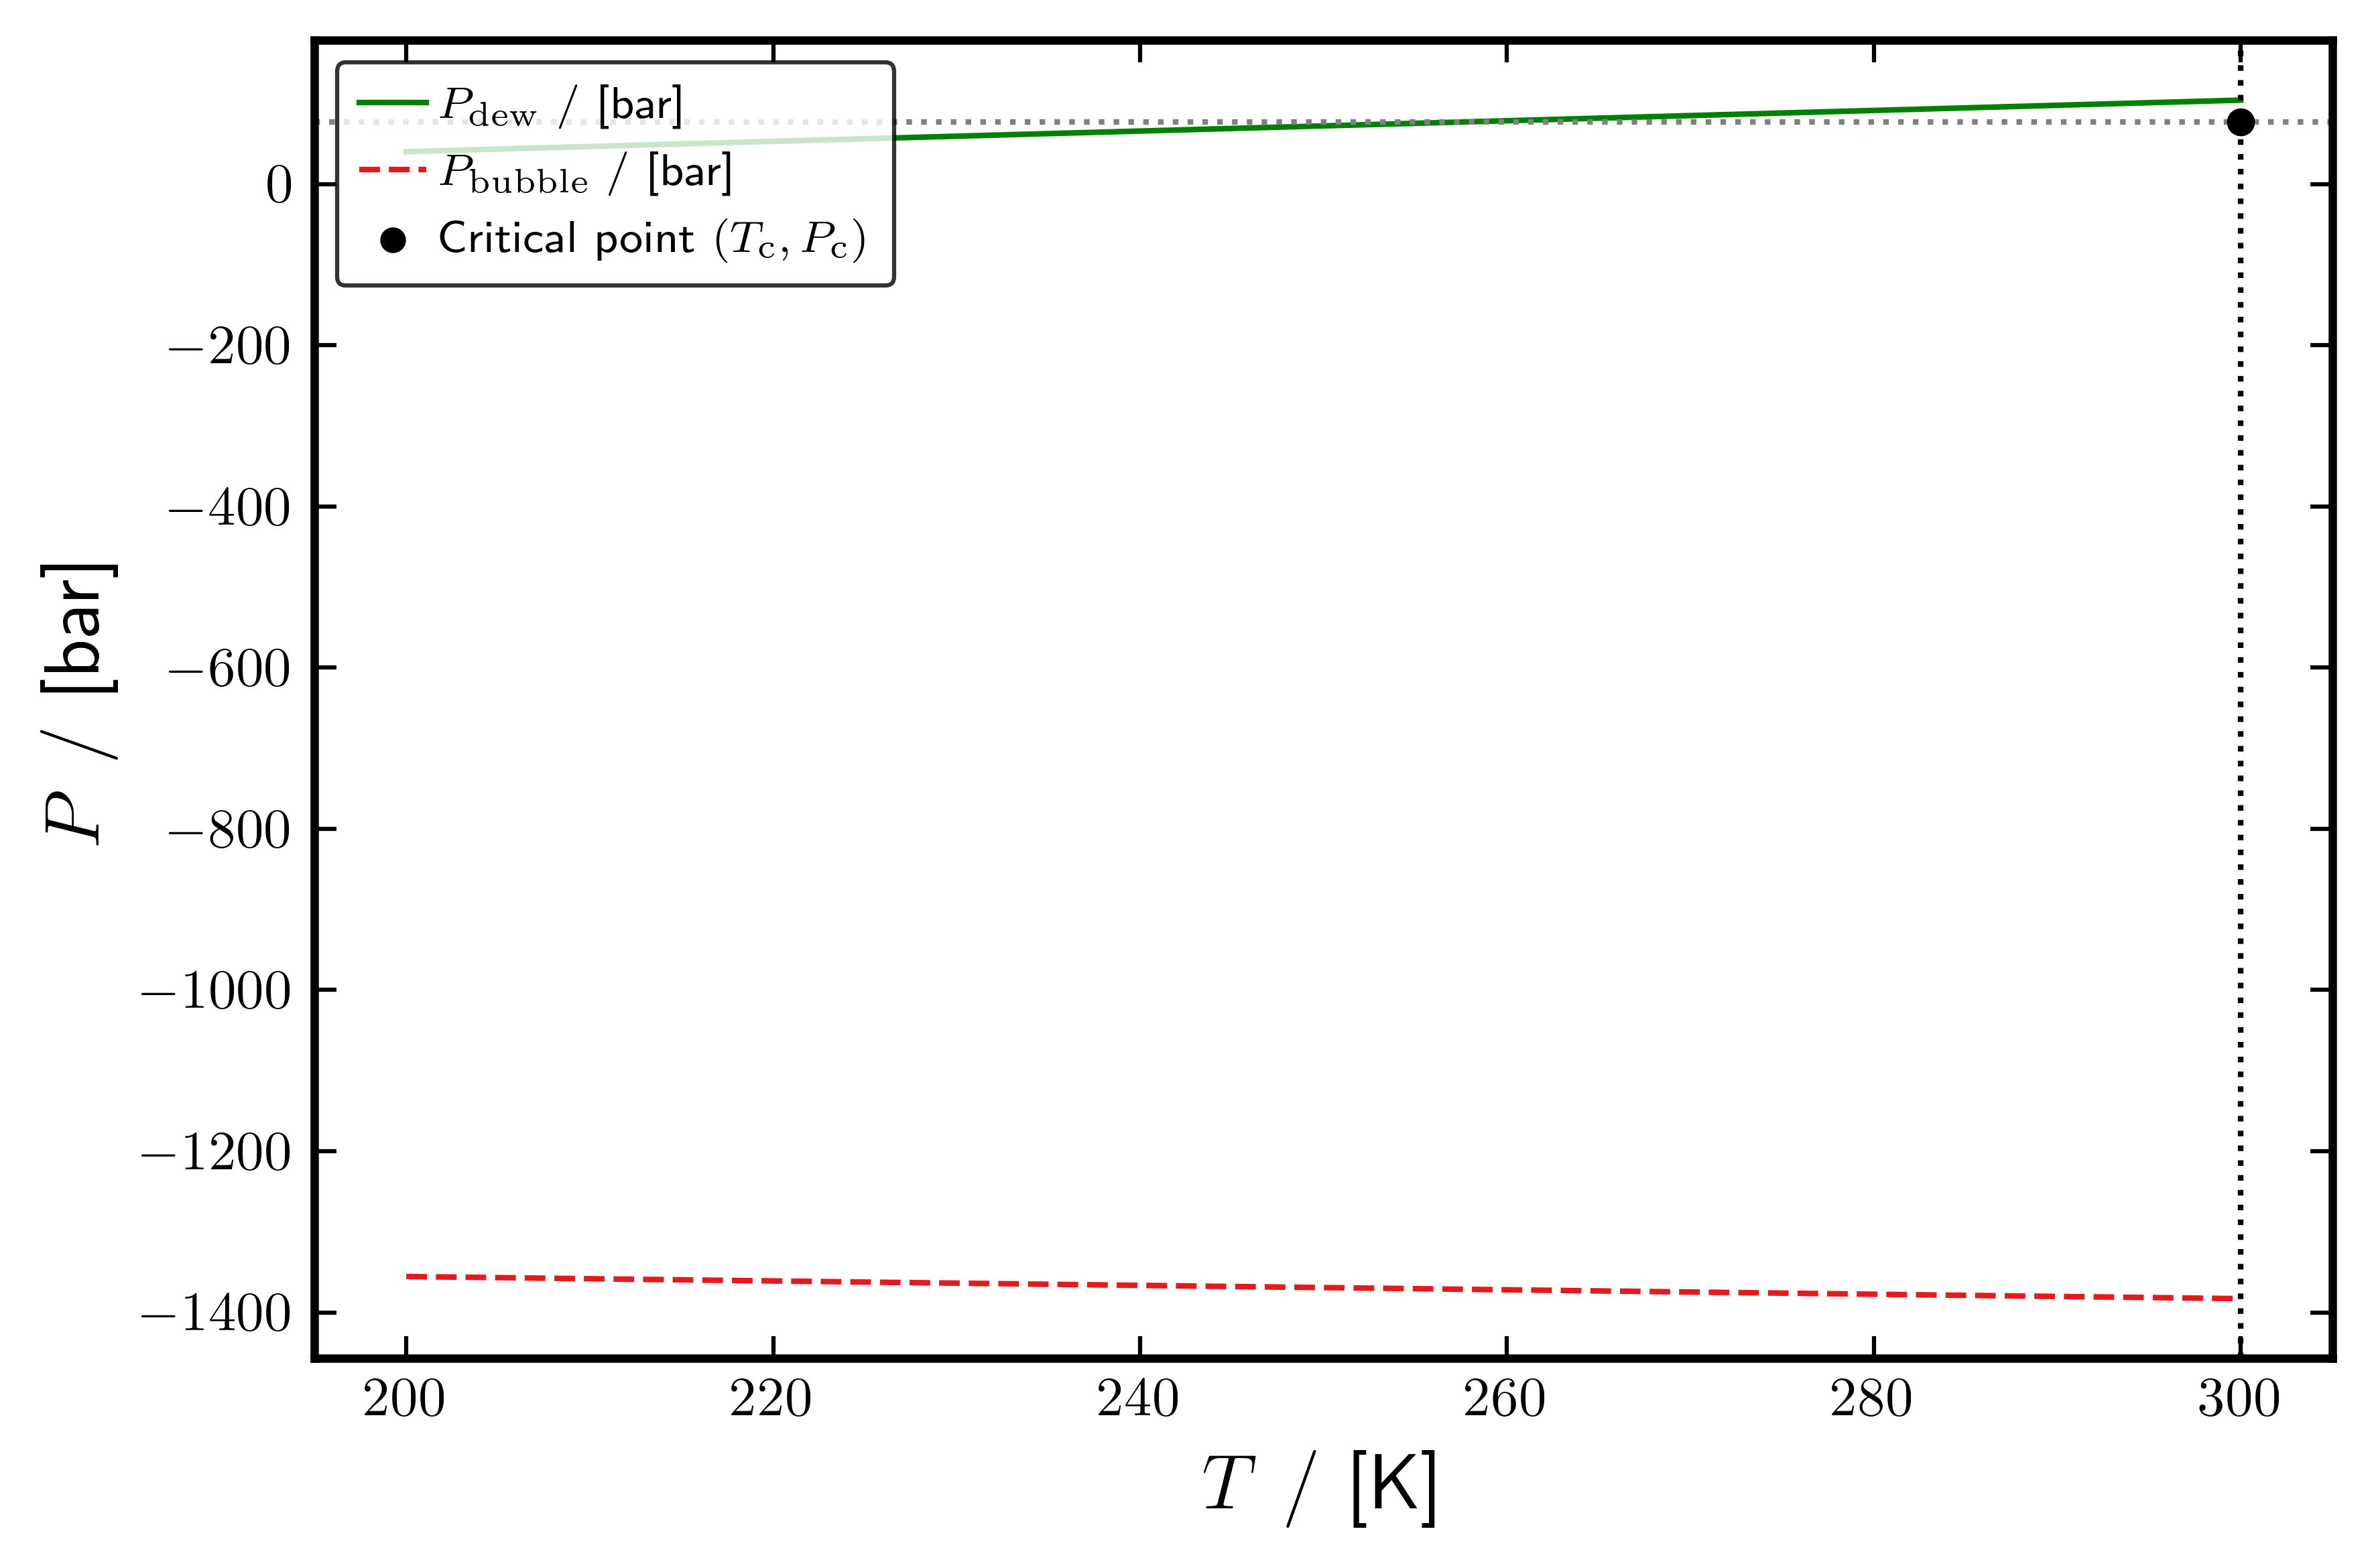

In [12]:

symbol_map = {k: ps.label_to_symbol(v) for k, v in ps.label_map.items()}

# --- fix capitalised keys to match X_train.columns ---
symbol_map["Tc"] = r"T_{\mathrm{c}}"
symbol_map["Pc"] = r"P_{\mathrm{c}}"

# --- declare sympy symbols ---
sym_vars = {
    name: sp.Symbol(symbol_map.get(name, symbol_map.get(name.lower(), name)))
    for name in X_train.columns
}

print("Declared symbols:")
for raw, sym in sym_vars.items():
    display(sp.Eq(sp.Symbol(raw), sym))

# ----------------------------------------------------------------
# POLYNOMIAL REGRESSION + EQUATIONS
# ----------------------------------------------------------------
degrees = [1]
results = {}

for degree in degrees:
    model_poly = Pipeline([
        ("poly",   PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])
    model_poly.fit(X_train, y_train)
    y_pred_poly = model_poly.predict(X_test)

    poly       = model_poly.named_steps["poly"]
    linear     = model_poly.named_steps["linear"]
    feat_names = poly.get_feature_names_out(X_train.columns)
    coef_df    = pd.DataFrame(
                    linear.coef_,
                    index=target,
                    columns=feat_names
                 )

    # --- build sympy equations ---
    equations = {}
    for t_idx, t in enumerate(target):
        expr = sp.Float(float(f"{linear.intercept_[t_idx]:.4g}"))

        for fname, coef in zip(feat_names, linear.coef_[t_idx]):
            coef_rounded = float(f"{coef:.4g}")
            if coef_rounded == 0:
                continue

            term = sp.Integer(1)
            for part in fname.split(" "):
                if "^" in part:
                    var, exp = part.split("^")
                    term *= sym_vars[var] ** int(exp)
                else:
                    term *= sym_vars[part]

            expr += sp.Float(coef_rounded) * term

        equations[t] = expr

    results[degree] = {
        "y_pred"    : y_pred_poly,
        "r2"        : [r2_score(y_test.iloc[:, i], y_pred_poly[:, i]) for i in range(len(target))],
        "rmse"      : [np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_poly[:, i])) for i in range(len(target))],
        "residuals" : y_test.values - y_pred_poly,
        "coef"      : coef_df,
        "intercept" : linear.intercept_,
        "equations" : equations,
    }

# --- display equations ---
print("\nEquations:")
for degree in degrees:
    print(f"\nDegree {degree}:")
    for t, eq in results[degree]["equations"].items():
        t_sym = sp.Symbol(symbol_map.get(t, symbol_map.get(t.lower(), t)))
        display(sp.Eq(t_sym, eq))

# ----------------------------------------------------------------
# PHASE ENVELOPE
# ----------------------------------------------------------------
user_inputs = {
    "Tc"         : 300.0,   # K
    "Pc"         : 77.0,    # bar
    "z_argon"    : 0.025,   # mol/mol
    "z_hydrogen" : 0.025,   # mol/mol
}

degree  = 1   # ← linear, no squared terms
T_sym   = sym_vars["temperature"]
T_range = np.linspace(200, user_inputs["Tc"], 300)

# --- substitute everything except T ---
fixed_vals = {
    sym_vars[col]: user_inputs[col]
    for col in X_train.columns
    if col != "temperature"
}

# --- evaluate curves ---
curves = {}
for t in target:
    eq        = results[degree]["equations"][t]
    eq_T      = eq.subs(fixed_vals)
    f_T       = sp.lambdify(T_sym, eq_T, modules="numpy")
    curves[t] = f_T(T_range)

# --- plot ---
fig, ax = ps.plot_init_multi(1, 1, w=6, h=4)

ax.plot(T_range, curves["P_dew"],
        color=ps.colors[1],
        linewidth=ps.linewidth,
        label=ps.label_map.get("p_dew", "P_dew"))

ax.plot(T_range, curves["P_bubble"],
        color=ps.colors[0],
        linewidth=ps.linewidth,
        label=ps.label_map.get("p_bubble", "P_bubble"))

# --- critical point ---
ax.scatter([user_inputs["Tc"]], [user_inputs["Pc"]],
           color="black",
           s=ps.markersize ** 2,
           zorder=5,
           label=r"Critical point $(T_{\mathrm{c}}, P_{\mathrm{c}})$")
ax.axvline(user_inputs["Tc"], color="black", linestyle=":",
           linewidth=ps.linewidth)
ax.axhline(user_inputs["Pc"], color="grey",  linestyle=":",
           linewidth=ps.linewidth)

ax.set_xlabel(ps.label_map.get("temperature", "T"), fontsize=ps.label_fontsize)
ax.set_ylabel(ps.label_map.get("pressure",    "P"), fontsize=ps.label_fontsize)
ps.style_legend(ax, loc="upper left")

plt.tight_layout()
plt.show()

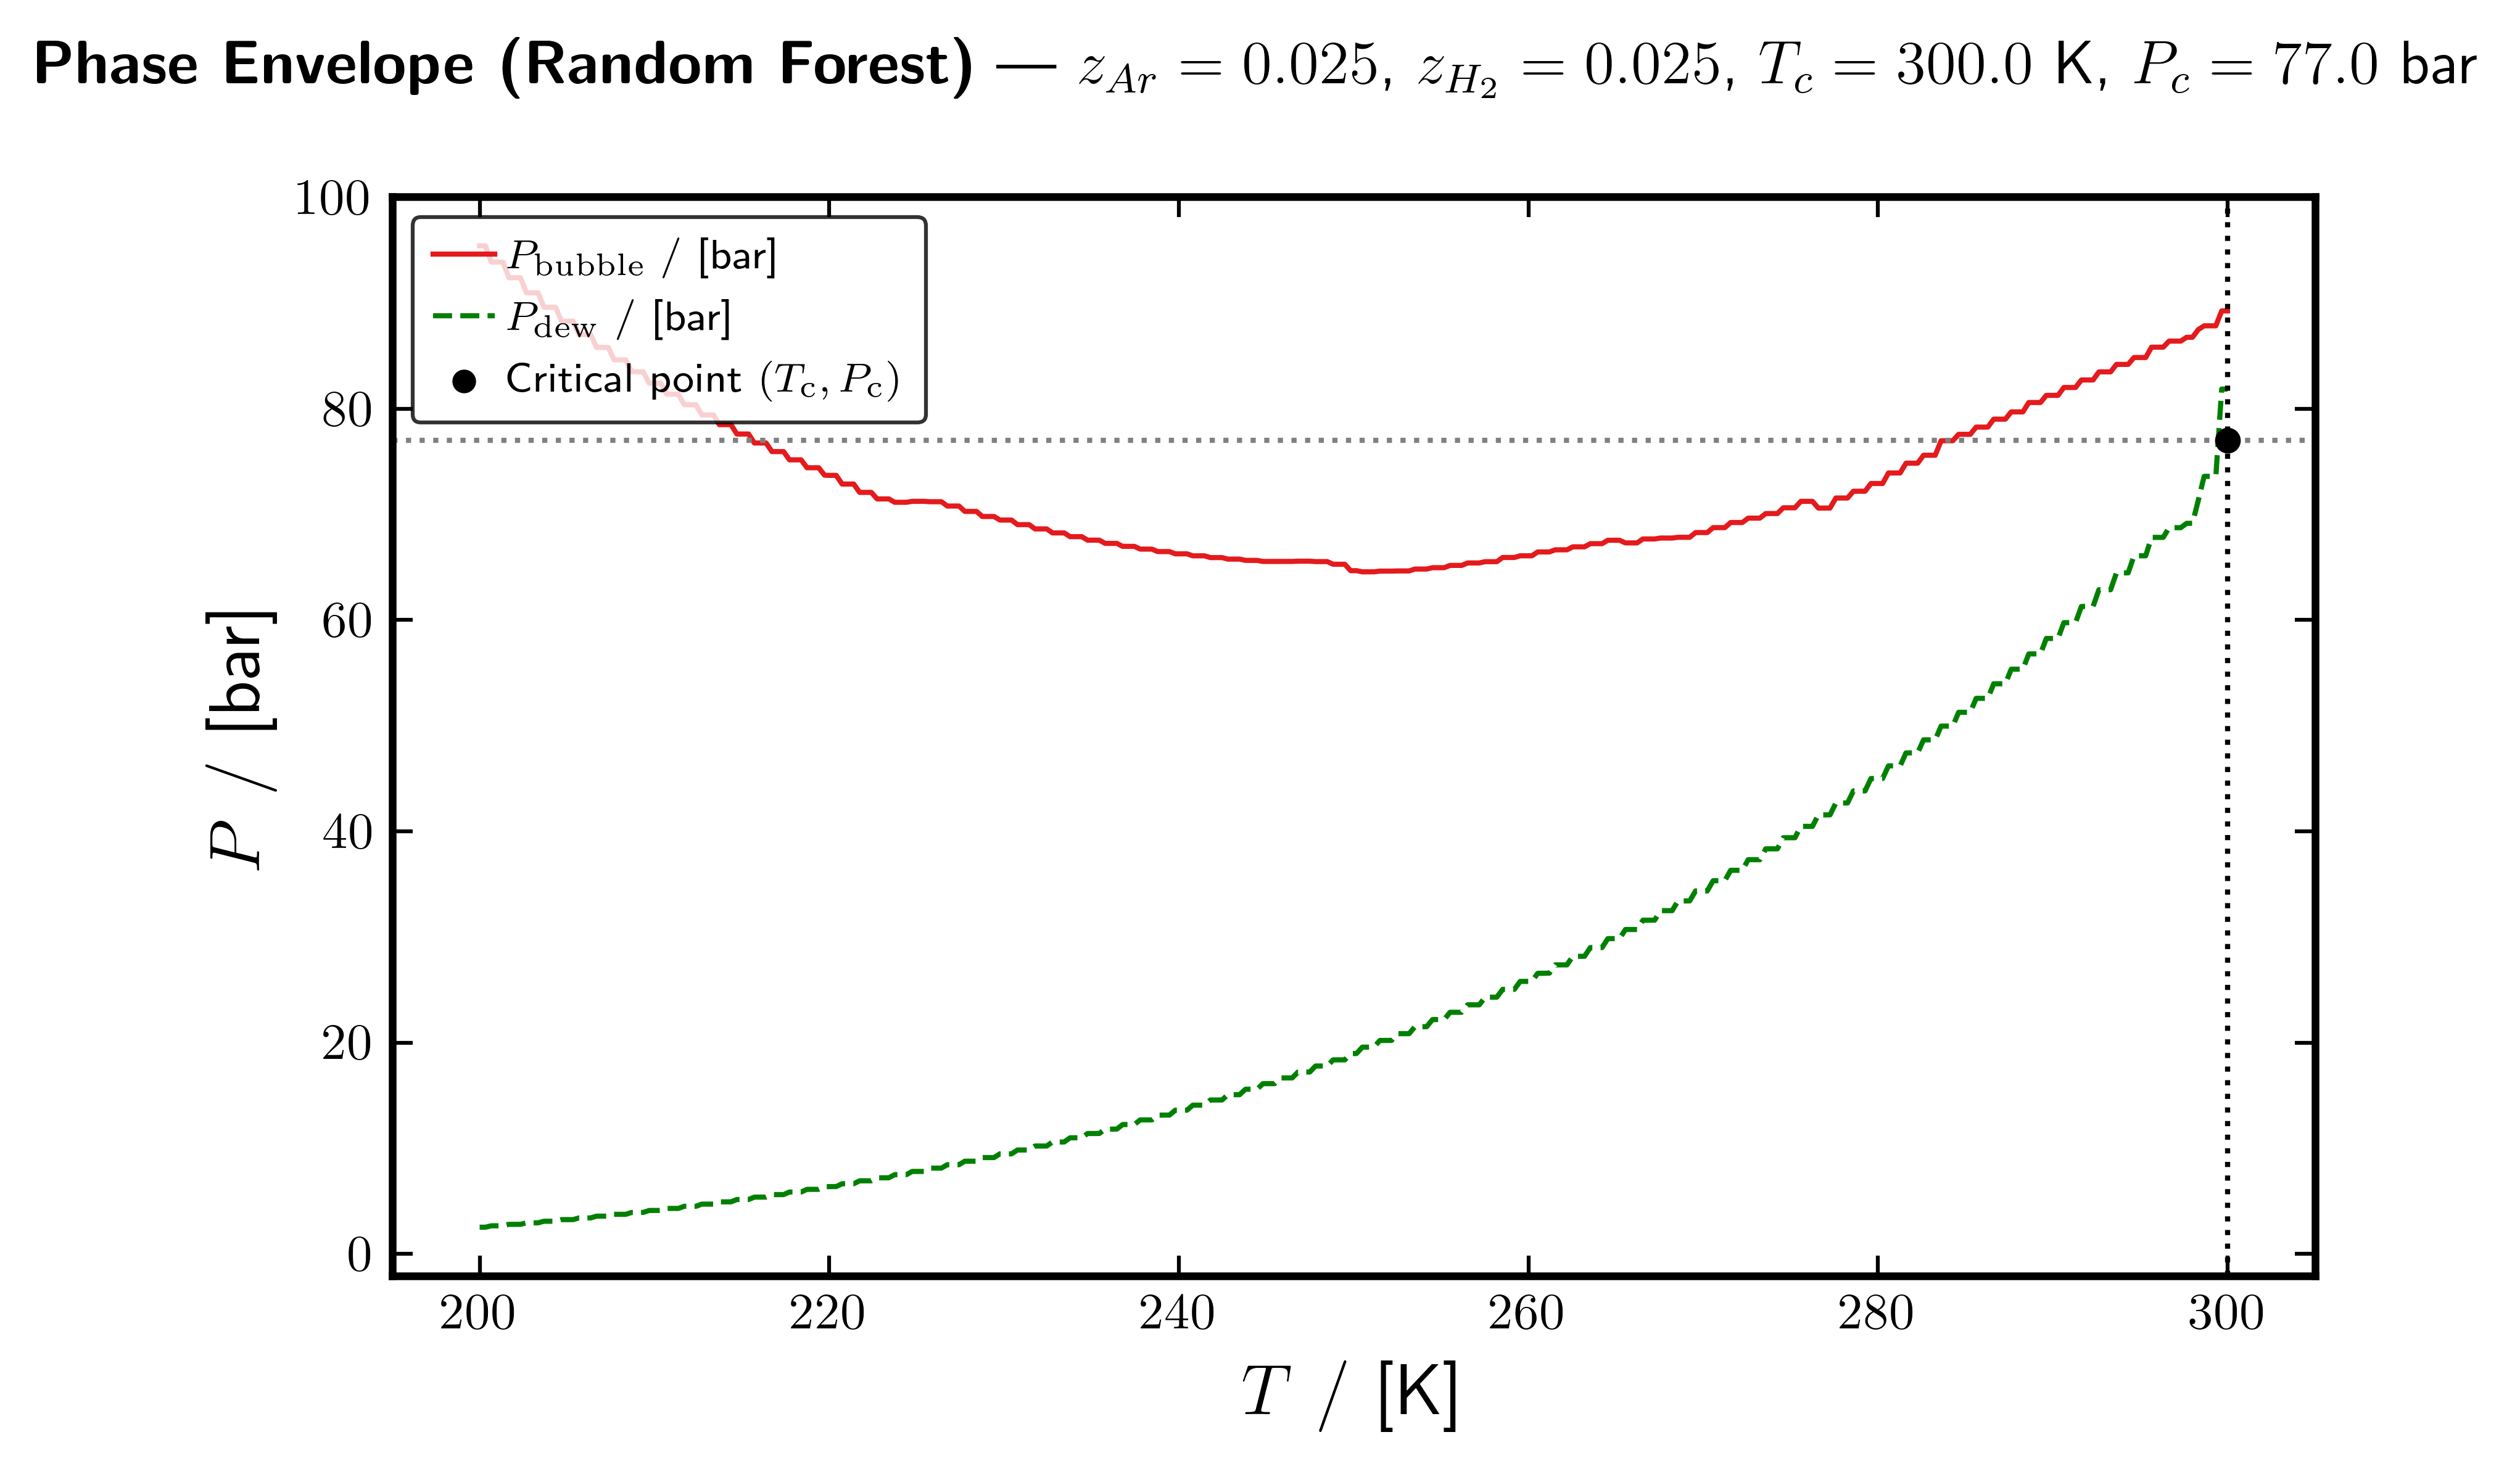

In [13]:
user_inputs = {
    "Tc"         : 300.0,   # K
    "Pc"         : 77.0,    # bar
    "z_argon"    : 0.025,   # mol/mol
    "z_hydrogen" : 0.025,   # mol/mol
}

T_range  = np.linspace(200, user_inputs["Tc"], 300)

# --- build input dataframe ---
input_df = pd.DataFrame({
    "temperature" : T_range,
    "Tc"          : user_inputs["Tc"],
    "Pc"          : user_inputs["Pc"],
    "z_argon"     : user_inputs["z_argon"],
    "z_hydrogen"  : user_inputs["z_hydrogen"],
}, columns=X_train.columns)

# --- predict ---
y_pred_rf_envelope = model_rf.predict(input_df)

# --- plot ---
fig, ax = ps.plot_init_multi(1, 1, w=6, h=4)

for i, t in enumerate(target):
    t_label = ps.label_map.get(t.lower(), t)
    ax.plot(T_range, y_pred_rf_envelope[:, i],
            color=ps.colors[i],
            linewidth=ps.linewidth,
            label=t_label)

ax.scatter([user_inputs["Tc"]], [user_inputs["Pc"]],
           color="black",
           s=ps.markersize ** 2,
           zorder=5,
           label=r"Critical point $(T_{\mathrm{c}}, P_{\mathrm{c}})$")
ax.axvline(user_inputs["Tc"], color="black", linestyle=":",
           linewidth=ps.linewidth)
ax.axhline(user_inputs["Pc"], color="grey",  linestyle=":",
           linewidth=ps.linewidth)

ax.set_xlabel(ps.label_map.get("temperature", "T"), fontsize=ps.label_fontsize)
ax.set_ylabel(ps.label_map.get("pressure",    "P"), fontsize=ps.label_fontsize)
ps.style_legend(ax, loc="upper left")

plt.suptitle(
    rf"\textbf{{Phase Envelope (Random Forest)}} --- "
    rf"$z_{{Ar}}={user_inputs['z_argon']}$, $z_{{H_2}}={user_inputs['z_hydrogen']}$, "
    rf"$T_c={user_inputs['Tc']}$ K, $P_c={user_inputs['Pc']}$ bar",
    fontsize=ps.title_fontsize
)
plt.tight_layout()
plt.show()

In [14]:
# model_sr_bubble = PySRRegressor(
#     niterations      = 500,
#     binary_operators = [
#         "+", "-", "*", "/",
#         "safepow(x::T, y::T) where T = x >= 0 ? T(x^y) : T(NaN)",  # ← T() cast
#     ],
#     unary_operators  = [
#         "square",
#         "cube(x::T) where T = T(x^3)",
#         "inv(x::T) where T = T(1/x)",
#         "invsquare(x::T) where T = T(1/x^2)",
#         "sqrt",
#         "safecbrt(x::T) where T = x >= 0 ? T(x^(1/3)) : T(NaN)",   # ← T() cast
#         "abs",
#     ],
#     extra_sympy_mappings = {
#         "cube"      : lambda x: x**3,
#         "inv"       : lambda x: 1/x,
#         "invsquare" : lambda x: 1/x**2,
#         "safecbrt"  : lambda x: x**(sp.Rational(1, 3)),
#         "safepow"   : lambda x, y: x**y,
#     },
#     populations      = 40,
#     maxsize          = 30,
#     parsimony        = 0.001,
#     random_state     = 42,
# )

# model_sr_dew = PySRRegressor(
#     niterations      = 500,
#     binary_operators = [
#         "+", "-", "*", "/",
#         "safepow(x::T, y::T) where T = x >= 0 ? T(x^y) : T(NaN)",
#     ],
#     unary_operators  = [
#         "square",
#         "cube(x::T) where T = T(x^3)",
#         "inv(x::T) where T = T(1/x)",
#         "invsquare(x::T) where T = T(1/x^2)",
#         "sqrt",
#         "safecbrt(x::T) where T = x >= 0 ? T(x^(1/3)) : T(NaN)",
#         "abs",
#     ],
#     extra_sympy_mappings = {
#         "cube"      : lambda x: x**3,
#         "inv"       : lambda x: 1/x,
#         "invsquare" : lambda x: 1/x**2,
#         "safecbrt"  : lambda x: x**(sp.Rational(1, 3)),
#         "safepow"   : lambda x, y: x**y,
#     },
#     populations      = 40,
#     maxsize          = 30,
#     parsimony        = 0.001,
#     random_state     = 42,
# )

# # --- fit ---
# model_sr_bubble.fit(X_train, y_train.iloc[:, 0])
# model_sr_dew.fit(X_train,    y_train.iloc[:, 1])

In [15]:

# hof = pd.read_csv("outputs/20260311_215610_jJFbXi/hall_of_fame.csv").dropna()

# hof["RMSE"] = np.sqrt(hof["Loss"])
# hof["R²"]   = 1 - (hof["Loss"] / np.var(y_train.iloc[:, 0]))  # for P_bubble or P_dew

# print(hof[["Complexity", "Loss", "RMSE", "R²", "Equation"]])

In [16]:
# local_dict = {
#     # key   = name as it appears in the CSV equation string
#     # value = your corresponding sympy symbol
#     "temperature" : sym_vars["temperature"],   # "temperature" → T
#     "Tc"          : sym_vars["Tc"],            # "Tc" → T_c
#     "Pc"          : sym_vars["Pc"],            # "Pc" → P_c
#     "z_argon"     : sym_vars["z_argon"],       # "z_argon" → z_Ar
#     "z_hydrogen"  : sym_vars["z_hydrogen"],    # "z_hydrogen" → z_H2
#     # math functions
#     "exp"         : sp.exp,
#     "log"         : sp.log,
#     "sqrt"        : sp.sqrt,
# }

In [17]:
# # --- read both hall of fame files ---
# hof_bubble = pd.read_csv("outputs/20260311_215412_gManFJ/hall_of_fame.csv").dropna()
# hof_dew    = pd.read_csv("outputs/20260311_215610_jJFbXi/hall_of_fame.csv").dropna()

# # --- pick best equation from each ---
# eq_str_bubble = hof_bubble.loc[hof_bubble["Loss"].idxmin(), "Equation"]
# eq_str_dew    = hof_dew.loc[hof_dew["Loss"].idxmin(),    "Equation"]

# print("Bubble equation:", eq_str_bubble)
# print("Dew equation:",    eq_str_dew)

# # --- parse ---
# eq_bubble = parse_expr(eq_str_bubble, local_dict=local_dict)
# eq_dew    = parse_expr(eq_str_dew,    local_dict=local_dict)

# # --- substitute fixed values ---
# T_sym      = sym_vars["temperature"]
# T_range    = np.linspace(200, user_inputs["Tc"], 300)
# fixed_vals = {
#     sym_vars[col]: user_inputs[col]
#     for col in X_train.columns
#     if col != "temperature"
# }

# P_bubble_vals = sp.lambdify(T_sym, eq_bubble.subs(fixed_vals), modules="numpy")(T_range)
# P_dew_vals    = sp.lambdify(T_sym, eq_dew.subs(fixed_vals),    modules="numpy")(T_range)

# # --- plot ---
# fig, ax = ps.plot_init_multi(1, 1, w=6, h=4)

# ax.plot(T_range, P_bubble_vals,
#         color=ps.colors[0],
#         linewidth=ps.linewidth,
#         label=ps.label_map.get("p_bubble", "P_bubble"))

# ax.plot(T_range, P_dew_vals,
#         color=ps.colors[1],
#         linewidth=ps.linewidth,
#         linestyle="--",
#         label=ps.label_map.get("p_dew", "P_dew"))

# ax.scatter([user_inputs["Tc"]], [user_inputs["Pc"]],
#            color="black",
#            s=ps.markersize ** 2,
#            zorder=5,
#            label=r"Critical point $(T_{\mathrm{c}}, P_{\mathrm{c}})$")
# ax.axvline(user_inputs["Tc"], color="black", linestyle=":",
#            linewidth=ps.linewidth)
# ax.axhline(user_inputs["Pc"], color="grey",  linestyle=":",
#            linewidth=ps.linewidth)

# ax.set_xlabel(ps.label_map.get("temperature", "T"), fontsize=ps.label_fontsize)
# ax.set_ylabel(ps.label_map.get("pressure",    "P"), fontsize=ps.label_fontsize)
# ps.style_legend(ax, loc="upper left")

# plt.suptitle(
#     rf"\textbf{{Phase Envelope (Symbolic Regression)}} --- "
#     rf"$z_{{Ar}}={user_inputs['z_argon']}$, $z_{{H_2}}={user_inputs['z_hydrogen']}$",
#     fontsize=ps.title_fontsize
# )
# plt.tight_layout()
# ps.save_plot(fig, "sr_phase_envelope_bubble_dew")
# plt.show()